# 02 — Biological modeling: weighted, MKM, and isoeffective dose

> **OpenBNCT is research software.** Nothing computed here is a clinical, equivalence, commissioning, or regulatory claim. See `docs/DISCLAIMER.md`.
>
> Run from the repository root after `pip install openbnct` (the notebooks read committed artifacts by repository-relative paths).

Physical dose is not the quantity clinicians weight — the mixed-field components carry different biological potency. This notebook applies the two biological surfaces: a fixed-weights biological model and the González & Santa Cruz isoeffective model (per-component dose-independent factors, √β cross-terms, Lea–Catcheside repair).

## Fixed-weights model

The model is a versioned artifact declaring per-component weights plus optional per-region overrides. Regions bind to `RegionMask` artifacts **by name** — the validator rejects a mask whose declared name doesn't match the model's region.

In [1]:
from pathlib import Path
import json, tempfile
import openbnct

# locate the repository root regardless of launch directory
REPO = Path.cwd()
while not (REPO / 'benchmarks').is_dir() and REPO != REPO.parent:
    REPO = REPO.parent
assert (REPO / 'benchmarks').is_dir(), 'run inside an OpenBNCT checkout'

BENCH = REPO / 'benchmarks/synthetic/layered-head-phantom'
bundle = openbnct.load_physical_dose_bundle(BENCH / 'dose-28g-v2.json')

model = openbnct.load_biological_model(
    REPO / 'examples/biological/fixed-component-weights-model-v1.json')
print(model.id, model.schema_version)

nctforge.examples.fixed-component-weights.v1 openbnct.biological-model/0.2.0


In [2]:
# The model declares a 'core' region override; the phantom's tumor
# mask is that region here. Masks bind by name, so write a copy
# carrying the region name the model expects.
mask = json.loads((BENCH / 'planning/tumor-mask.json').read_text())
mask['name'] = 'core'
tmp = Path(tempfile.mkdtemp())
mask_path = tmp / 'core-mask.json'
mask_path.write_text(json.dumps(mask))

bio = openbnct.apply_model(model, bundle, [('core', str(mask_path))])
print('regions applied:', bio.regions_applied)
print('weight semantics:', bio.weight_semantics)
print('qualification:', bio.qualification)

regions applied: ['core']
weight semantics: fixed_per_component
qualification: synthetic_research_only_not_clinical


Each component keeps its weighted volume; the biological total is their sum. Compare maxima against the physical bundle:

In [3]:
for c in bio.components:
    print(f'{c.component:<10} max weighted {max(c.values):.3e} '
          f'{c.unit}')
print(f'{"biological_total":<10} max {max(bio.biological_total.values):.3e} '
      f'{bio.unit}')

boron      max weighted 6.913e-16 weighted_gray_per_source_particle
hydrogen   max weighted 1.649e-13 weighted_gray_per_source_particle
nitrogen   max weighted 1.719e-14 weighted_gray_per_source_particle
photon     max weighted 5.479e-13 weighted_gray_per_source_particle
biological_total max 7.128e-13 weighted_gray_per_source_particle


## González & Santa Cruz isoeffective dose

The fixed-weights model is the dose-independent-factor approximation. The IsoE model keeps per-component `rbe` (linear term) and `rbe_beta` (√β synergy) separate and inverts the mixed-field exponent once against the photon LQ. Models can be authored inline — `make_isoeffective_model` runs the same validation the file path does.

In [4]:
iso = openbnct.make_isoeffective_model({
    'schema_version': 'openbnct.isoeffective-model/0.1.0',
    'id': 'notebooks.gs-isoeffective.demo',
    'input_unit': 'gray_per_source_particle',
    'alpha_0': 0.02,
    'beta': 0.01,
    'components': {
        'boron':    {'rbe': 3.8, 'rbe_beta': 4.9},
        'nitrogen': {'rbe': 2.5, 'rbe_beta': 2.5},
        'hydrogen': {'rbe': 3.2, 'rbe_beta': 3.2},
        'photon':   {'rbe': 1.0, 'rbe_beta': 1.0},
    },
    'region_factors': {
        'tumor': {
            'boron':    {'rbe': 4.9, 'rbe_beta': 4.9},
            'nitrogen': {'rbe': 2.5, 'rbe_beta': 2.5},
            'hydrogen': {'rbe': 3.2, 'rbe_beta': 3.2},
            'photon':   {'rbe': 1.0, 'rbe_beta': 1.0},
        },
    },
    'validity_domain': 'notebook demonstration factors; '
                       'not a clinical model',
})
isoe = openbnct.apply_isoeffective(
    iso, bundle, [('tumor', str(
        BENCH / 'planning/tumor-mask.json'))])
print('weight semantics:', isoe.weight_semantics)
for c in isoe.components:
    print(f'{c.component:<10} max {max(c.values):.3e} {c.unit}')

weight semantics: photon_isoeffective
boron      max 6.913e-16 isoeffective_gray_per_source_particle
hydrogen   max 1.649e-13 isoeffective_gray_per_source_particle
nitrogen   max 1.719e-14 isoeffective_gray_per_source_particle
photon     max 5.479e-13 isoeffective_gray_per_source_particle


## Fixed-weights vs IsoE, head to head

Same factors where comparable — the difference is the combined-then-inverted exponent (Zaider–Rossi cross terms) versus per-component inversion summed after.

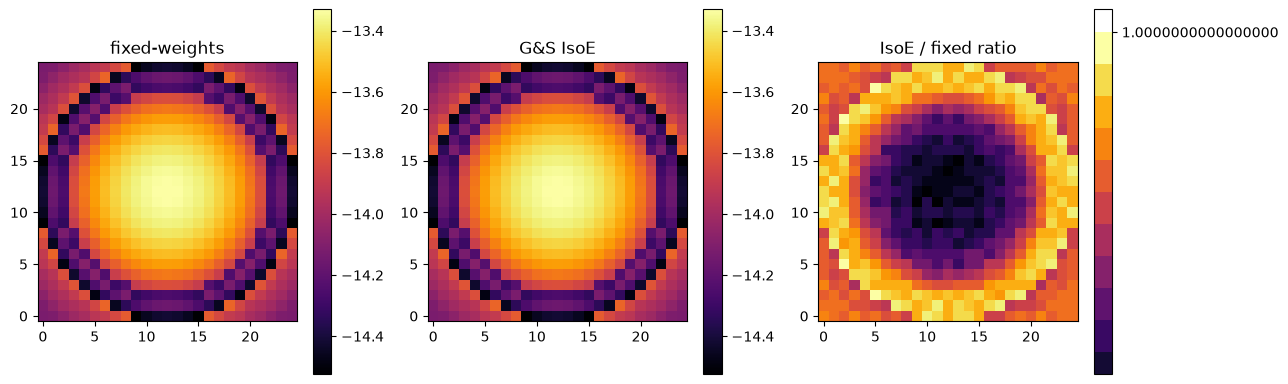

In [5]:
import matplotlib.pyplot as plt
import numpy as np

nx, ny, nz = bundle.geometry.shape
# x-fastest voxel order → C-order reshape (nz, ny, nx); mid z-plane.
a = np.array(bio.biological_total.values).reshape(nz, ny, nx)[nz // 2]
c = np.array(isoe.biological_total.values).reshape(nz, ny, nx)[nz // 2]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, vol, title in zip(axes, [a, c, c / np.maximum(a, 1e-30)],
                          ['fixed-weights', 'G&S IsoE', 'IsoE / fixed ratio']):
    im = ax.imshow(np.log10(vol + 1e-30) if 'ratio' not in title
                   else vol, origin='lower', cmap='inferno')
    ax.set_title(title)
    fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

**Next:** `03-uncertainty.ipynb` — the evaluated-covariance chain that no other BNCT tool ships.